In [10]:
import ast
import pandas as pd
cell_history_df1 = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/script/12052026_exhaustion.csv.gz", compression='gzip')
cell_history_df2 = pd.read_csv("C:\\Szonja\\UNI\\FYP\\MantiShrimp-main - Copy\\18052026_exhaustion.csv.gz", compression='gzip')
cell_history_df3 = pd.read_csv("C:\\Szonja\\UNI\\FYP\\MantiShrimp-main - Copy\\01062026_exhaustion.csv.gz", compression='gzip')
cell_history_df4 = pd.read_csv("C:\\Szonja\\UNI\\FYP\\MantiShrimp-main - Copy\\02062026_exhaustion.csv.gz", compression='gzip')


In [13]:
# Cell 0 — after loading
cell_history_df1["run_id"] = 0
cell_history_df2["run_id"] = 1
cell_history_df3["run_id"] = 2
cell_history_df4["run_id"] = 3

# Cell 1 — concat stays the same
cell_history_df = pd.concat([cell_history_df1, cell_history_df2, cell_history_df3, cell_history_df4], ignore_index=True)

In [ ]:


# ─── Extract one row per death event ──────────────────────────────────────────
# Strategy: for each target cell, take the first step where Death_Factor >= 1.0
# (this is the frame the kill is registered). killed_by holds the list of
# NK cell IDs responsible.

targets = cell_history_df[cell_history_df["cell_type"] == "target"].copy()

death_frames = (
    targets[targets["Death_Factor"] >= 1.0]
    .sort_values("step")
    .groupby("cell_id", as_index=False)
    .first()          # earliest step at/above threshold = the kill step
)


def _parse_list(val):
    """Safely parse a stringified list; returns [] on null/malformed."""
    if pd.isna(val):
        return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [parsed]
    except (ValueError, SyntaxError):
        return []

death_frames["killed_by_list"] = death_frames["killed_by"].apply(_parse_list)
death_frames["n_killers"]       = death_frames["killed_by_list"].apply(len)


def _classify(n: int) -> str:
    if n == 0:
        return "unattributed"   # Death_Factor hit 1.0 but killed_by is empty
    elif n == 1:
        return "solo"
    else:
        return "collaborative"

death_frames["kill_type"] = death_frames["n_killers"].apply(_classify)


kill_summary = (
    death_frames["kill_type"]
    .value_counts()
    .rename_axis("kill_type")
    .reset_index(name="count")
)
kill_summary["proportion"] = kill_summary["count"] / kill_summary["count"].sum()
kill_summary["percent"]    = kill_summary["proportion"] * 100

print(kill_summary.to_string(index=False))
print(f"\nTotal kills recorded: {len(death_frames)}")


KILL_COLOURS = {
    "solo":          "#4C72B0",
    "collaborative": "#DD8452",
    "unattributed":  "#8C8C8C",
}

kill_plot_data = [
    (
        row["proportion"],
        row["kill_type"].capitalize(),
        KILL_COLOURS.get(row["kill_type"], "#AAAAAA"),
    )
    for _, row in kill_summary.iterrows()
]

    kill_type  count  proportion   percent
         solo    333    0.997006 99.700599
collaborative      1    0.002994  0.299401

Total kills recorded: 334


In [ ]:


targets = cell_history_df[cell_history_df["cell_type"] == "target"].copy()

death_frames = (
    targets[targets["Death_Factor"] >= 1.0]
    .sort_values("step")
    .groupby("cell_id", as_index=False)
    .first()
)


def _parse_contacts(val):
    """
    Safely parse contacts whether they are stored as:
    - actual lists: [1, 2]
    - stringified lists: "[1, 2]"
    - empty lists: []
    - NaN / malformed values
    """
    if isinstance(val, list):
        return val

    if pd.isna(val):
        return []

    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            return parsed if isinstance(parsed, list) else [parsed]
        except (ValueError, SyntaxError):
            return []

    return []

death_frames["contacts_list"] = death_frames["contacts"].apply(_parse_contacts)
death_frames["n_contacting_killers"] = death_frames["contacts_list"].apply(len)


def _classify_from_contacts(n: int) -> str:
    if n == 0:
        return "unattributed"
    elif n == 1:
        return "solo"
    else:
        return "collaborative"

death_frames["kill_type"] = death_frames["n_contacting_killers"].apply(_classify_from_contacts)

kill_summary = (
    death_frames["kill_type"]
    .value_counts()
    .rename_axis("kill_type")
    .reset_index(name="count")
)

kill_summary["proportion"] = kill_summary["count"] / kill_summary["count"].sum()
kill_summary["percent"] = kill_summary["proportion"] * 100

print(kill_summary.to_string(index=False))
print(f"\nTotal kills recorded: {len(death_frames)}")

death_frames[[
    "cell_id",
    "step",
    "time",
    "Death_Factor",
    "contacts",
    "contacts_list",
    "n_contacting_killers",
    "kill_type"
]]

    kill_type  count  proportion   percent
         solo    332    0.994012 99.401198
collaborative      2    0.005988  0.598802

Total kills recorded: 334


,cell_id,step,time,Death_Factor,contacts,contacts_list,n_contacting_killers,kill_type
0,0,5006,65.369850,1.0,[75],[75],1,solo
1,1,328,4.834532,1.0,[18],[18],1,solo
2,2,880,11.147448,1.0,[29],[29],1,solo
3,3,375,5.185403,1.0,[76],[76],1,solo
4,4,1246,15.799441,1.0,[41],[41],1,solo
...,...,...,...,...,...,...,...,...
329,394,4815,63.255692,1.0,[96],[96],1,solo
330,396,627,8.096452,1.0,[90],[90],1,solo
331,397,740,9.505590,1.0,[6],[6],1,solo
332,398,392,5.446359,1.0,[27],[27],1,solo


In [ ]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


TIME_UNIT = "hours"  
INCLUDE_CENSORED = True 
MIN_LIFETIME_MIN = 0   

# ─── Parse contacts ──────────────────────────────────────────────────────────

def _parse_contacts(val):
    if isinstance(val, list):
        return val
    if pd.isna(val):
        return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError, TypeError):
        return []

df = cell_history_df.copy()
df["contacts"] = df["contacts"].apply(_parse_contacts)

required_cols = {"cell_type", "cell_id", "step", "time", "contacts"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Convert time to minutes
if TIME_UNIT == "hours":
    df["time_min"] = df["time"] * 60
elif TIME_UNIT == "minutes":
    df["time_min"] = df["time"]
else:
    raise ValueError("TIME_UNIT must be either 'hours' or 'minutes'.")

# Quick sanity check
time_check = (
    df[["step", "time", "time_min"]]
    .drop_duplicates()
    .sort_values("step")
)

print("Time check:")
print(time_check.head(10).to_string(index=False))
print(time_check.tail(10).to_string(index=False))
print("\nMedian timestep in minutes:", time_check["time_min"].diff().median())
print("Max simulation time in minutes:", time_check["time_min"].max())

# ─── Extract target records ──────────────────────────────────────────────────

target_df = (
    df[df["cell_type"] == "target"]
    .sort_values(["cell_id", "step"])
    .copy()
)


synapse_events = []

for (run_id, target_id), g in target_df.groupby(["run_id", "cell_id"], sort=False):
    g = g.sort_values("step")

    steps = g["step"].to_numpy()
    times = g["time_min"].to_numpy()
    contacts = g["contacts"].to_numpy()

    active = {}  # nk_id -> start info

    for step, time_min, curr_contacts in zip(steps, times, contacts):
        curr = set(curr_contacts)
        prev = set(active.keys())

        # New synapses
        for nk_id in curr - prev:
            active[nk_id] = {
                "start_step": step,
                "start_time_min": time_min,
            }

        # Dissolved synapses
        for nk_id in prev - curr:
            start = active.pop(nk_id)

            lifetime_min = time_min - start["start_time_min"]
            lifetime_steps = step - start["start_step"]

            if lifetime_min >= MIN_LIFETIME_MIN and lifetime_min > 0:
                synapse_events.append({
                    "target_id": target_id,
                    "nk_id": nk_id,
                    "start_step": start["start_step"],
                    "end_step": step,
                    "lifetime_steps": lifetime_steps,
                    "start_time_min": start["start_time_min"],
                    "end_time_min": time_min,
                    "lifetime_min": lifetime_min,
                    "end_reason": "dissolved",
                })

    final_step = steps[-1]
    final_time_min = times[-1]

    for nk_id, start in active.items():
        lifetime_min = final_time_min - start["start_time_min"]
        lifetime_steps = final_step - start["start_step"]

        if lifetime_min >= MIN_LIFETIME_MIN and lifetime_min > 0:
            synapse_events.append({
                "target_id": target_id,
                "nk_id": nk_id,
                "start_step": start["start_step"],
                "end_step": final_step,
                "lifetime_steps": lifetime_steps,
                "start_time_min": start["start_time_min"],
                "end_time_min": final_time_min,
                "lifetime_min": lifetime_min,
                "end_reason": "censored/end",
            })

synapse_df = pd.DataFrame(synapse_events)

if synapse_df.empty:
    raise ValueError("No synapse events found. Check whether target contacts contain NK cell IDs.")


if INCLUDE_CENSORED:
    plot_df = synapse_df.copy()
    plot_note = "all synapses"
else:
    plot_df = synapse_df[synapse_df["end_reason"] == "dissolved"].copy()
    plot_note = "naturally dissolved synapses only"

lifetimes = plot_df["lifetime_min"].to_numpy()

Time check:
 step  time  time_min
    0  0.00       0.0
    1  0.04       2.4
    2  0.08       4.8
    3  0.12       7.2
    4  0.16       9.6
    5  0.20      12.0
    6  0.24      14.4
    7  0.28      16.8
    8  0.32      19.2
    9  0.36      21.6
 step      time    time_min
 6072 79.908627 4794.517615
 6073 79.948433 4796.906009
 6074 79.948998 4796.939868
 6075 79.949749 4796.984941
 6076 79.950931 4797.055876
 6077 79.953479 4797.208760
 6078 79.993394 4799.603660
 6079 79.994143 4799.648586
 6080 79.995298 4799.717850
 6081 79.997740 4799.864383

Median timestep in minutes: 0.2783194313478816
Max simulation time in minutes: 4799.864383155523



Synapse lifetime summary:
               Metric    Value
       Total synapses 1768.000
   Dissolved synapses 1753.000
Censored/end synapses   15.000
  Mean lifetime (min)   42.245
Median lifetime (min)   38.117
   Min lifetime (min)    0.109
   Max lifetime (min)  317.444
25th percentile (min)   18.871
75th percentile (min)   61.746

Lifetime counts by number of steps:
 lifetime_steps  count
              1      9
              2     17
              3     16
              4     21
              5     13
              6      8
              7     16
              8     30
              9     20
             10     16
             11     12
             12     21
             13     24
             14     14
             15     20
             16     18
             17     20
             18     17
             19     15
             20     23
             21     25
             22     21
             23     23
             24     21
             25     10
             26     15
     

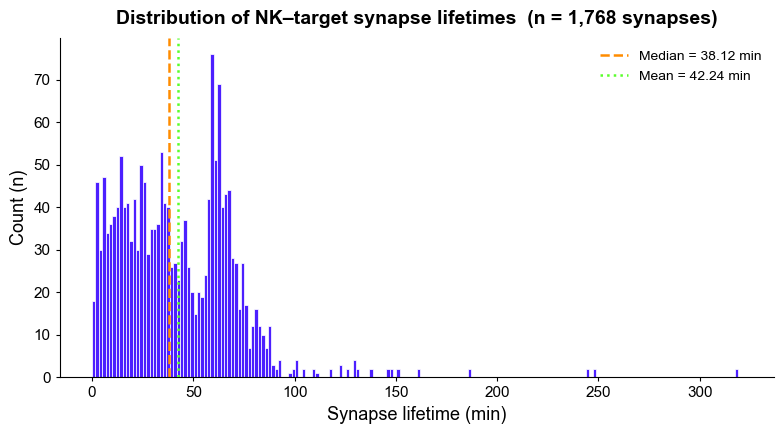

In [ ]:


summary_table = pd.DataFrame({
    "Metric": [
        "Total synapses",
        "Dissolved synapses",
        "Censored/end synapses",
        "Mean lifetime (min)",
        "Median lifetime (min)",
        "Min lifetime (min)",
        "Max lifetime (min)",
        "25th percentile (min)",
        "75th percentile (min)"
    ],
    "Value": [
        len(synapse_df),
        (synapse_df["end_reason"] == "dissolved").sum(),
        (synapse_df["end_reason"] == "censored/end").sum(),
        synapse_df["lifetime_min"].mean(),
        synapse_df["lifetime_min"].median(),
        synapse_df["lifetime_min"].min(),
        synapse_df["lifetime_min"].max(),
        synapse_df["lifetime_min"].quantile(0.25),
        synapse_df["lifetime_min"].quantile(0.75),
    ]
})

summary_table["Value"] = summary_table["Value"].round(3)

print("\nSynapse lifetime summary:")
print(summary_table.to_string(index=False))

print("\nLifetime counts by number of steps:")
print(
    plot_df["lifetime_steps"]
    .value_counts()
    .sort_index()
    .rename_axis("lifetime_steps")
    .reset_index(name="count")
    .to_string(index=False)
)

plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family":      "Arial",
    "font.size":        12,
    "axes.labelsize":   13,
    "axes.titlesize":   14,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
})

fig, ax = plt.subplots(figsize=(8, 4.5))

bin_width = time_check["time_min"].diff().median()
step_min = bin_width * 6  # finer bins to capture discrete step durations
max_life = lifetimes.max()
bins     = np.arange(0, max_life + 2 * step_min, step_min)

n, edges, patches = ax.hist(
    lifetimes,
    bins=bins,
    color="#3300FF",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.88,
)

median_val = np.median(lifetimes)
ax.axvline(
    median_val,
    color="#FF8C00",
    linewidth=1.8,
    linestyle="--",
    label=f"Median = {median_val:.2f} min",
)

mean_val = np.mean(lifetimes)
ax.axvline(
    mean_val,
    color="#5afe2c",
    linewidth=1.8,
    linestyle=":",
    label=f"Mean = {mean_val:.2f} min",
)

ax.set_xlabel("Synapse lifetime (min)")
ax.set_ylabel("Count (n)")
ax.set_title(
    f"Distribution of NK–target synapse lifetimes  "
    f"(n = {len(lifetimes):,} synapses)",
    pad=10,
    fontweight="semibold",
)

ax.legend(frameon=False, fontsize=10)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(length=3, width=0.8)

plt.tight_layout()
plt.savefig("synapse_lifetime_dist.png", dpi=180, bbox_inches="tight")
plt.show()

In [41]:
summary_table.to_csv("synapse_lifetime_summary.csv", index=False)

In [21]:
n_total = len(synapse_df)
n_censored = (synapse_df["end_reason"] == "censored/end").sum()

error_rate = n_censored / n_total
error_percent = 100 * error_rate

print(f"Error/censoring rate: {error_rate:.4f} ({error_percent:.2f}%)")

Error/censoring rate: 0.0085 (0.85%)


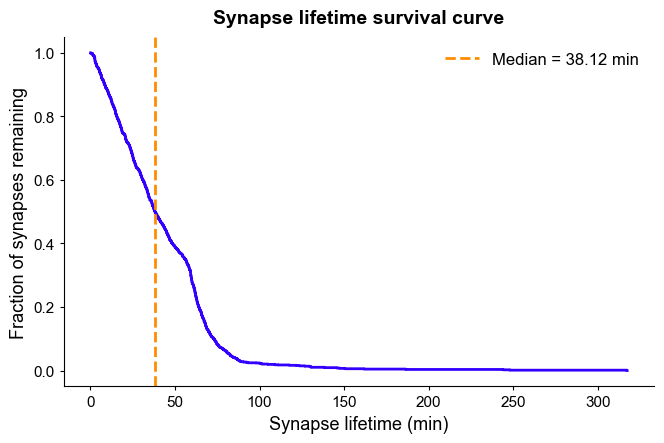

,target_id,nk_id,start_step,end_step,lifetime_steps,start_time_min,end_time_min,lifetime_min,end_reason
0,0,86,4123,4134,11,3186.125053,3195.070469,8.945417,dissolved
1,0,86,4157,4191,34,3212.324597,3245.742891,33.418294,dissolved
2,0,86,5389,5448,59,4204.076376,4244.627053,40.550678,dissolved
3,0,75,4634,4720,86,3630.384250,3699.911419,69.527169,dissolved
4,0,75,4771,4959,188,3736.416588,3881.970485,145.553896,dissolved


In [ ]:
sorted_life = np.sort(lifetimes)
survival = 1 - np.arange(1, len(sorted_life) + 1) / len(sorted_life)

fig, ax = plt.subplots(figsize=(6.8, 4.6))

ax.step(
    sorted_life,
    survival,
    where="post",
    linewidth=2,
    color="#3300FF"
)

ax.axvline(
    median_val,
    color="#FF8C00",
    linewidth=2,
    linestyle="--",
    label=f"Median = {median_val:.2f} min"
)

ax.set_xlabel("Synapse lifetime (min)")
ax.set_ylabel("Fraction of synapses remaining")
ax.set_title(
    "Synapse lifetime survival curve",
    pad=10,
    fontweight="semibold"
)

ax.legend(frameon=False)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.tick_params(length=3, width=0.8)

plt.tight_layout()
plt.savefig("synapse_lifetime_survival_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# optional: inspect the extracted synapse table
synapse_df.head()